# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Grefal, Jesse Rudyll
- _Student No._: 20XX-XXXXX
- _Section_: THR-TX-3

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 (You may edit this subsection)

![Description](./figures/sample.png)

EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` (for more info, check bottomost cell under Section 3). Make sure the figure has complete elements.

### Problem 2 (You may edit this subsection)

EDIT ME. See instruction above for what to include. Insert your discussion here. This is not related to Problem 1. Discuss your key results with ~150 words.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

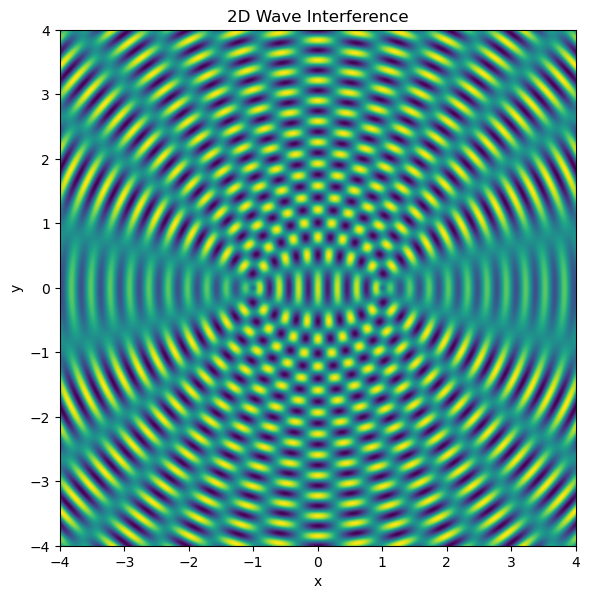

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# insert your code here
A = 1.0                                                           # parameters
k = 2*np.pi / 0.3
r0 = ([-1.0 , 0.0])
r1 = ([1.0 , 0.0])

n =1000                                                           # grid
x = np.linspace (-4 , 4 , n)           
y = np.linspace (-4 , 4 , n)
X, Y = np.meshgrid (x, y)

dist0 = np.sqrt ((X - r0[0])**2 + (Y - r0[1])**2)                 # Distances |r-r0| and |r-r1|
dist1 = np.sqrt ((X - r1[0])**2 + (Y - r1[1])**2)

W = A*np.sin(k*dist0) + A*np.sin(k*dist1)                         # Wave field

fig, ax = plt.subplots (figsize = (6, 9))                         # Plot
im = ax.imshow (W, extent = [-4, 4, -4, 4], origin = 'lower')
plt.xlabel ('x' , fontsize = 10)
plt.ylabel ('y' , fontsize = 10)
ax.set_title ('2D Wave Interference')
plt.tight_layout()
plt.savefig('2D_Wave_Interference,png')
plt.show()

# The script above visualizes the interference of two circular waves from sources at (-1, 0) and (1, 0) by computing sin(k·distance) from each source across a grid and summing them. 
# I used meshgrid with vectorized array math so the whole field is computed at once, and set imshow with origin='lower' and extent=[-4,4,-4,4] so the plot shows physical coordinates the right way up.
# The grid is 800×800 because the wavelength (0.3) is small, and a coarse grid would alias the fine fringes into a false pattern.


# your output should look something like this
# do not forget axes labels 

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [27]:
import random
number = random.randint(1, 9)
number

4

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [41]:
def random_integer_matrix(nrows, ncols):
    """ 
    Return an nrows xncols matrix (list of lists) of random ints in [1, 9]
    """
    return [[random.randint(1, 9) for _ in range(ncols)] for _ in range(nrows)]

matrix = random_integer_matrix(3, 4) # call the function to create a 3x4 matrix
matrix

# This builds an nrows × ncols list-of-lists filled with random integers from 1 to 9. 
# I used a nested list comprehension where the outer loop makes rows and the inner loop fills cells, which is the idiomatic way to construct a 2D structure without manual appending.

[[9, 2, 5, 3], [9, 6, 5, 8], [8, 7, 8, 6]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [36]:
# write your code for b here
def scalar_product(list1, list2):
    """
    Dot product of two equal-length lists: sum of elementwise products.
    """
    return sum(a*b for a, b in zip(list1, list2))

# This returns the dot product of two lists by pairing elements with zip, multiplying each pair, and summing. 
# I used zip inside sum to avoid tracking indices manually. 
# It relies on equal-length inputs, which matrix_multiply guarantees.

In [32]:
# write your code for b here
def scalar_product(list1, list2):
    """
    Dot product of two equal-length lists: sum of elementwise products.
    """
    return sum(a*b for a, b in zip(list1, list2))

list_1 = [1, 2, 4, 5, 7, 8]
list_2 = [3, 6, 9, 12]

scalar_product(list_1, list_2)

111

In [ ]:
# use as many cell blocks as you want (as long as they all are functional)
# include valuable comments (even for trivial functions, a one-liner will do)

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [35]:
# write your code for c here
def transpose_matrix(orig_matrix):
    """
    Return the transpose of a matrix (list of lists), of any shape
    """
    return [list(row) for row in zip(*orig_matrix)]

# This returns the transpose of any matrix by using zip(*orig_matrix) to regroup rows into columns, wrapping each in list() to keep list-of-lists form. 
# I chose this because it makes no assumption about the matrix dimensions and works for any shape.

In [45]:
# write your code for c here
def transpose_matrix(orig_matrix):
    """
    Return the transpose of a matrix (list of lists), of any shape
    """
    return [list(row) for row in zip(*orig_matrix)]

omatrix = [[9, 2, 5, 3], [9, 6, 5, 8], [8, 7, 8, 6]]
transpose_matrix(omatrix)

[[9, 9, 8], [2, 6, 7], [5, 5, 8], [3, 8, 6]]

d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [34]:
# write your code for d here
def matrix_multiply(left_matrix, right_matrix):
    """
    Multiply an (m x n) matrix by an (n x p) matrix which results to a (m x p) matrix, lists of lists
    """
    n_left_cols = len (left_matrix[0])
    n_right_rows = len (right_matrix)
    if n_left_cols != n_right_rows:
        raise ValueError (
            f"incompatible shapes: left has {n_left_cols} cols, "
            f"right has {n_right_rows} rows"
        )
    right_T = transpose_matrix(right_matrix)   # columns of right become rows
    return [[scalar_product(row, col) for col in right_T] for row in left_matrix]

# This multiplies two matrices by transposing the right one so its columns become rows, then taking the dot product of each left-row with each right-column, reusing the parts b and c helpers. 
# I added a shape check that raises ValueError on mismatched inner dimensions, because otherwise the zip-based dot product would silently truncate and return a wrong answer instead of failing.

In [49]:
# write your code for d here
def matrix_multiply(left_matrix, right_matrix):
    """
    Multiply an (m x n) matrix by an (n x p) matrix -> (m x p), lists of lists
    """
    n_left_cols = len (left_matrix[0])
    n_right_rows = len (right_matrix)
    if n_left_cols != n_right_rows:
        raise ValueError (
            f"incompatible shapes: left has {n_left_cols} cols, "
            f"right has {n_right_rows} rows"
        )
    right_T = transpose_matrix(right_matrix)   # columns of right become rows
    return [[scalar_product(row, col) for col in right_T] for row in left_matrix]

left = random_integer_matrix(2, 3)
right = random_integer_matrix(3, 4)
product = matrix_multiply(left, right)
product

[[120, 72, 48, 60], [121, 63, 35, 45]]

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.